# FLUX Image-to-Image Canny 🗒️🖼️

⚠️ **Remember to copy this notebook in your Drive and rename.**

🤗 This notebook uses [Hugging Face Diffusers](https://huggingface.co/docs/diffusers/en/index) to create pipelines for tasks such as image generation.

*Workflows for IAAC MaCDA GenAI  (Apr - Jun 2026) taught by [James McBennett](https://www.linkedin.com/in/mcbennett/) and [Aymeric Brouez](https://www.linkedin.com/in/aymeric-brouez/)*

*With special thanks to past faculty [Nono Martínez Alonso](https://youtube.com/NonoMartinezAlonso).*

***Workflow requires A100 runtime**


### Mount Drive

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Hugging Face Token

In [ ]:
# Sign up at Hugging Face and create a "Read" access token (not the default "Fine-Grained" token).
# Click the 🔑 "Secrets" icon in the left sidebar.
# Enable Notebook Access, Set the Name to "HF_TOKEN", Paste your token as the Value

from google.colab import userdata
hf_token = userdata.get("HF_TOKEN")

## Setup

In [ ]:
%cd /content
!rm -rf iaac_genai
!git clone https://github.com/jamesmcbennett/iaac_genai
%cd /content/iaac_genai/

/content
Cloning into 'creative-image-generation'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 137 (delta 68), reused 104 (delta 39), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 33.36 KiB | 11.12 MiB/s, done.
Resolving deltas: 100% (68/68), done.
/content/creative-image-generation


In [ ]:
import sys
sys.path.append('/content/iaac_genai')

In [ ]:
!pip install -q -r requirements.txt --quiet > /dev/null 2>&1

In [ ]:
from config import Config
from utils import set_image_path, save_image, save_yml, save_svg
import torch

from diffusers.utils import load_image
from PIL import Image
import numpy as np
import cv2

## Output Directory

In [ ]:
Config.OUTPUT_DIR = '/content/drive/MyDrive/iaac_genai/outputs'

## Canny

array([[[122, 149, 216],
        [124, 151, 218],
        [125, 152, 219],
        ...,
        [156, 180, 224],
        [156, 180, 224],
        [156, 180, 224]],

       [[121, 148, 215],
        [122, 149, 216],
        [123, 150, 217],
        ...,
        [156, 180, 224],
        [156, 180, 224],
        [156, 180, 224]],

       [[126, 153, 220],
        [126, 153, 220],
        [125, 152, 219],
        ...,
        [156, 180, 224],
        [156, 180, 224],
        [156, 180, 224]],

       ...,

       [[131,  55,  16],
        [111,  49,   3],
        [139,  68,  18],
        ...,
        [ 70,  68,  82],
        [ 76,  74,  91],
        [ 79,  78,  97]],

       [[139,  61,  23],
        [113,  52,   7],
        [132,  67,  19],
        ...,
        [ 24,  34,  47],
        [ 22,  32,  48],
        [ 19,  29,  49]],

       [[145,  64,  27],
        [112,  52,   7],
        [123,  64,  18],
        ...,
        [ 26,  46,  60],
        [ 29,  48,  66],
        [ 32,  51,  73]]], dtype=uint8)
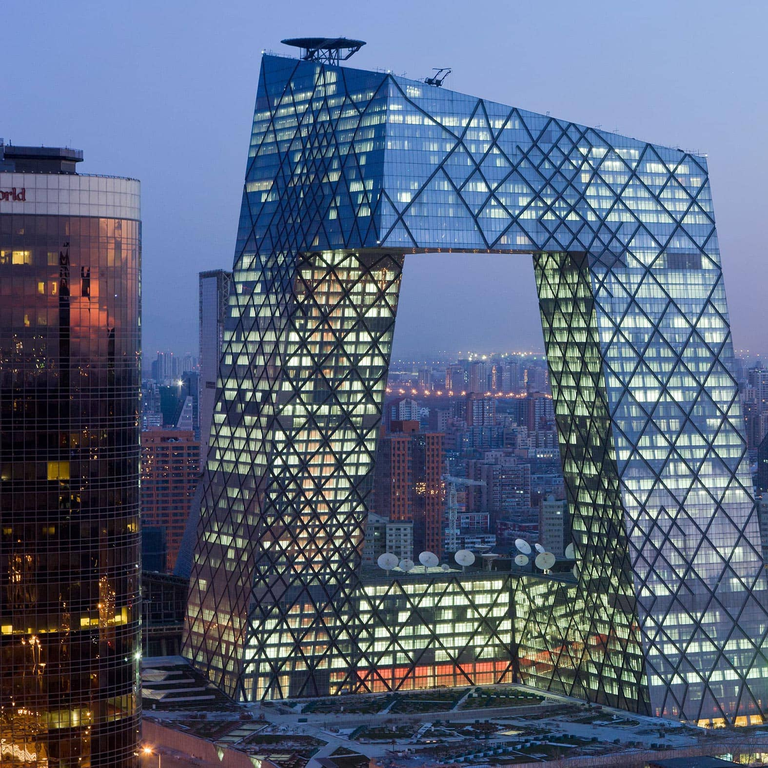

In [ ]:
# See options below on loading an image from Google drive or from an online link
#input_image = load_image("/content/drive/MyDrive/input/sample_image.png")
input_image = load_image("https://buro-os.com/upload/project/c4f2e8f9bae005543595f22ecf638a90.jpg")
resolution = 768

#Square
w, h = input_image.size
square_dim = min(w, h)
input_image = input_image.crop((0, 0, square_dim, square_dim))

#Resize
max_dim = resolution
input_image = input_image.resize((max_dim, max_dim), Image.LANCZOS)

input_image_np = np.array(input_image)
input_image_np

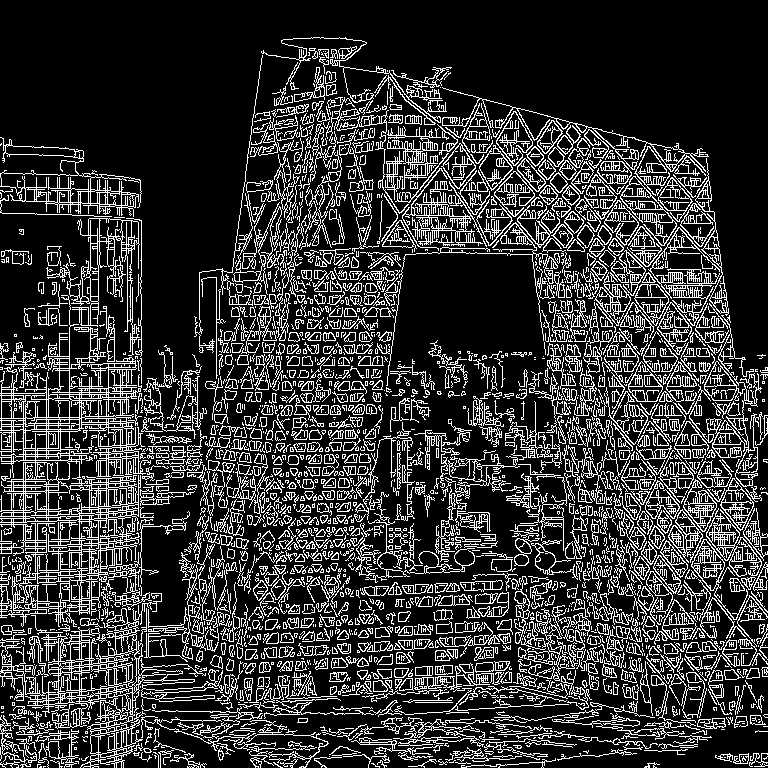

In [ ]:
# Get canny image
canny_image = cv2.Canny(input_image_np, 0, 300) #lower to upper threshold / sensitivity to edges
canny_image = canny_image[:, :, None]
canny_image = np.concatenate([canny_image, canny_image, canny_image], axis=2)
canny_image = Image.fromarray(canny_image)

# download an image
#image = np.array(canny_image)
canny_image

## Load pipeline

Load a pipeline with Hugging Face Diffusers.

In [ ]:
# Create pipeline (2 min load on A100)
from diffusers import FluxControlNetPipeline, FluxControlNetModel

base_model = 'black-forest-labs/FLUX.1-dev'
controlnet_model_union = 'Shakker-Labs/FLUX.1-dev-ControlNet-Union-Pro-2.0'
controlnet = FluxControlNetModel.from_pretrained(controlnet_model_union, torch_dtype=torch.bfloat16, token=hf_token)
pipe = FluxControlNetPipeline.from_pretrained(base_model, controlnet=controlnet, torch_dtype=torch.bfloat16,token=hf_token)
pipe.to("cuda")

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/4.28G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/536 [00:00<?, ?B/s]

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 108.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 90.12 MiB is free. Process 3592 has 14.65 GiB memory in use. Of the allocated memory 14.55 GiB is allocated by PyTorch, and 564.50 KiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Config

You can override parameters here.

In [ ]:
Config.PROMPT = 'an architectural model of a skyscaper made of balsa wood'
Config.SEED = 7797676568
Config.STEPS = 28

Config.AUTHOR = 'James'
Config.ALGO_TYPE = 'Image to Image'
Config.ALGO_NAME = 'Flux.1 Dev Canny'

Config.check()

## Generate

In [ ]:
# Generate.
generator = torch.Generator(Config.TORCH_DEVICE).manual_seed(Config.SEED)

controlnet_conditioning_scale=0.7
control_guidance_end=0.8
guidance_scale=3.5

generator = torch.Generator(Config.TORCH_DEVICE).manual_seed(Config.SEED)
image = pipe(Config.PROMPT, control_image=canny_image, height=resolution, width=resolution, controlnet_conditioning_scale=controlnet_conditioning_scale, control_guidance_end=control_guidance_end, num_inference_steps=Config.STEPS, guidance_scale=guidance_scale, max_sequence_length=256, generator=generator).images[0]
set_image_path()

display(image)

## Save

Save the pipeline and config metadata, generated image, and the parameters image.

In [ ]:
# Save image
save_image(image)

In [ ]:
# Save yml metadata
save_yml(pipe)

In [ ]:
# Save svg parameters image
save_svg({
    'SEED': Config.SEED,
    'STEPS': Config.STEPS,
    'Google Colab': '',
})

## Disconnect

In [ ]:
from google.colab import runtime
runtime.unassign()